<a href="https://colab.research.google.com/github/hariprakashg/Data-Analysis-Projects/blob/main/Loan_approval_secondaryAxis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/loan_approval_dataset.csv')

In [ ]:
df.columns = df.columns.str.strip()
df['loan_status'] = df['loan_status'].str.strip()

df['loan_amount'] = pd.cut(df['loan_amount'], bins=20)

grouped = df.groupby('loan_amount', observed=False).agg(
    Count=('loan_amount', 'count'),
    Approval_Rate=('loan_status', lambda x: (x == 'Approved').mean())
).reset_index()

grouped['loan_amount'] = grouped['loan_amount'].astype(str)


/tmp/ipykernel_161/1821357987.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(grouped['loan_amount'], rotation=45)


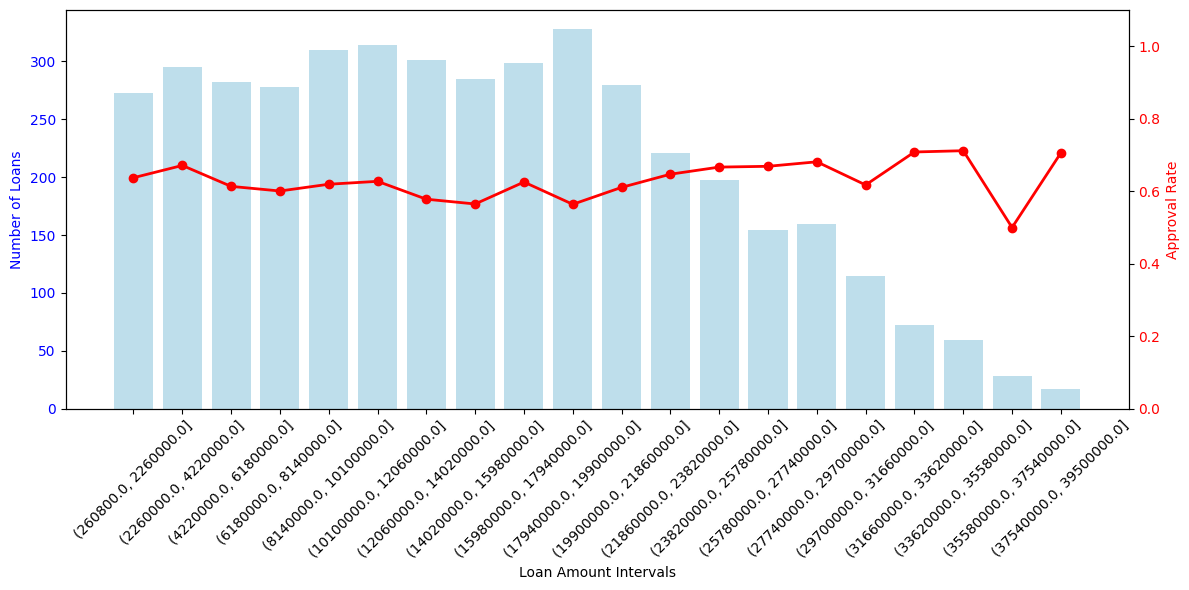

In [ ]:

fig, ax1 = plt.subplots(figsize=(12, 6))

sns.barplot(data=grouped, x='loan_amount', y='Count', color='skyblue', ax=ax1, alpha=0.6)
ax1.set_ylabel('Number of Loans', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_xlabel('Loan Amount Intervals')
ax1.set_xticklabels(grouped['loan_amount'], rotation=45)

ax2 = ax1.twinx()
ax2.plot(grouped['loan_amount'], grouped['Approval_Rate'], color='red', marker='o', linewidth=2, linestyle='-')
ax2.set_ylabel('Approval Rate', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, 1.1)

plt.tight_layout()


In [ ]:
print(df.isnull().sum())

loan_id                     0
no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64


In [ ]:
print(df.duplicated().sum())

0


In [ ]:
print(df.describe)

<bound method NDFrame.describe of       loan_id  no_of_dependents      education self_employed  income_annum  \
0           1                 2       Graduate            No       9600000   
1           2                 0   Not Graduate           Yes       4100000   
2           3                 3       Graduate            No       9100000   
3           4                 3       Graduate            No       8200000   
4           5                 5   Not Graduate           Yes       9800000   
...       ...               ...            ...           ...           ...   
4264     4265                 5       Graduate           Yes       1000000   
4265     4266                 0   Not Graduate           Yes       3300000   
4266     4267                 2   Not Graduate            No       6500000   
4267     4268                 1   Not Graduate            No       4100000   
4268     4269                 1       Graduate            No       9200000   

                   loan_amoun

In [ ]:
print(df.columns)

Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='object')


In [ ]:
print(df.dtypes )

loan_id                        int64
no_of_dependents               int64
education                     object
self_employed                 object
income_annum                   int64
loan_amount                 category
loan_term                      int64
cibil_score                    int64
residential_assets_value       int64
commercial_assets_value        int64
luxury_assets_value            int64
bank_asset_value               int64
loan_status                   object
dtype: object


In [ ]:
df.columns = df.columns.str.strip()
print(df['loan_status'].unique())

['Approved' 'Rejected']


In [ ]:
print(df['self_employed'].unique())

[' No' ' Yes']


In [ ]:
print(df['education'].unique())

[' Graduate' ' Not Graduate']


In [ ]:
df['loan_status']=df['loan_status'].str.strip().map({'Approved':1,'Rejected':0})
df['loan_status'].astype(int)

,loan_status
0,1
1,0
2,0
3,0
4,0
...,...
4264,0
4265,1
4266,0
4267,1


In [ ]:
print(df['loan_status'].unique())

[1 0]


In [ ]:
print(df.head())

   loan_id  no_of_dependents      education self_employed  income_annum  \
0        1                 2       Graduate            No       9600000   
1        2                 0   Not Graduate           Yes       4100000   
2        3                 3       Graduate            No       9100000   
3        4                 3       Graduate            No       8200000   
4        5                 5   Not Graduate           Yes       9800000   

                loan_amount  loan_term  cibil_score  residential_assets_value  \
0  (29700000.0, 31660000.0]         12          778                   2400000   
1  (12060000.0, 14020000.0]          8          417                   2700000   
2  (27740000.0, 29700000.0]         20          506                   7100000   
3  (29700000.0, 31660000.0]          8          467                  18200000   
4  (23820000.0, 25780000.0]         20          382                  12400000   

   commercial_assets_value  luxury_assets_value  bank_asset_va

In [ ]:
df['education']=df['education'].str.strip().map({'Graduate':1,'Not Graduate':0})
df['education'].astype(int)

,education
0,1
1,0
2,1
3,1
4,0
...,...
4264,1
4265,0
4266,0
4267,0


In [ ]:
df['self_employed']=df['self_employed'].str.strip().map({'Yes':1,'No':0})
df['self_employed'].astype(int)


,self_employed
0,0
1,1
2,0
3,0
4,1
...,...
4264,1
4265,1
4266,0
4267,0


In [ ]:
cols=['loan_id', 'no_of_dependents', 'education', 'self_employed',
        'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
        'residential_assets_value', 'commercial_assets_value',
        'luxury_assets_value', 'bank_asset_value', 'loan_status']
cols

['loan_id',
 'no_of_dependents',
 'education',
 'self_employed',
 'income_annum',
 'loan_amount',
 'loan_term',
 'cibil_score',
 'residential_assets_value',
 'commercial_assets_value',
 'luxury_assets_value',
 'bank_asset_value',
 'loan_status']

In [ ]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,1,0,9600000,"(29700000.0, 31660000.0]",12,778,2400000,17600000,22700000,8000000,1
1,2,0,0,1,4100000,"(12060000.0, 14020000.0]",8,417,2700000,2200000,8800000,3300000,0
2,3,3,1,0,9100000,"(27740000.0, 29700000.0]",20,506,7100000,4500000,33300000,12800000,0
3,4,3,1,0,8200000,"(29700000.0, 31660000.0]",8,467,18200000,3300000,23300000,7900000,0
4,5,5,0,1,9800000,"(23820000.0, 25780000.0]",20,382,12400000,8200000,29400000,5000000,0


<Axes: xlabel='loan_status', ylabel='no_of_dependents'>

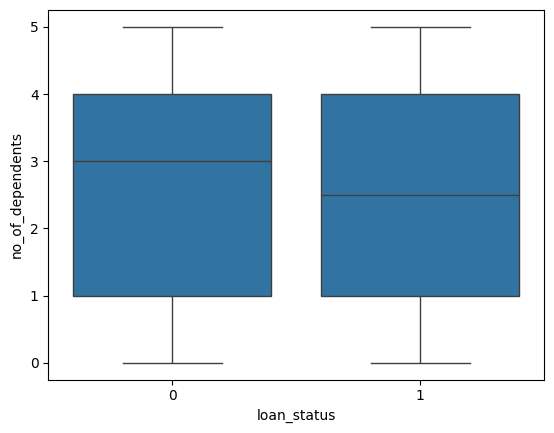

In [ ]:
sns.boxplot(x=df['loan_status'],y=df['no_of_dependents'])

<Axes: xlabel='loan_status', ylabel='income_annum'>

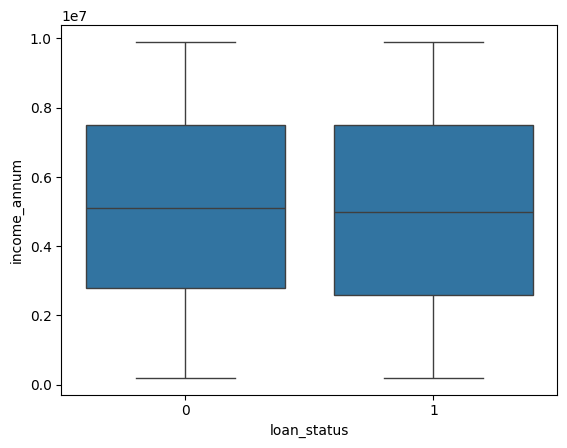

In [ ]:
sns.boxplot(x=df['loan_status'],y=df['income_annum'])

<Axes: xlabel='loan_status', ylabel='cibil_score'>

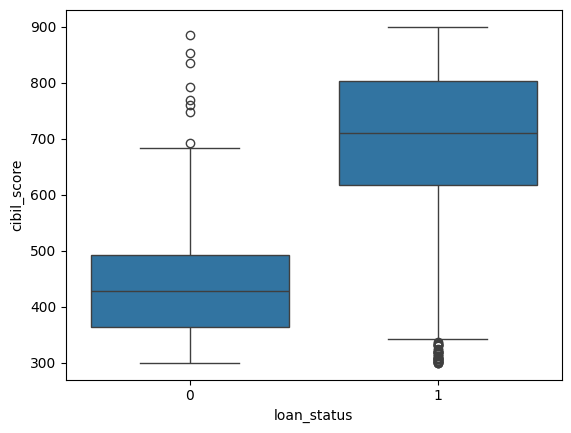

In [ ]:
sns.boxplot(x=df['loan_status'],y=df['cibil_score'])

<Axes: xlabel='loan_status', ylabel='loan_term'>

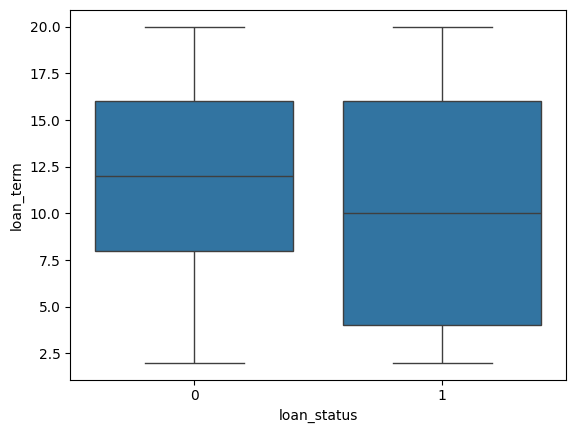

In [ ]:
sns.boxplot(x=df['loan_status'],y=df['loan_term'])

In [ ]:
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix



In [ ]:

df = pd.read_csv('loan_approval_dataset.csv')

df.columns = df.columns.str.strip()

le = LabelEncoder()
for col in ['education', 'self_employed', 'loan_status']:
    df[col] = df[col].str.strip()
    df[col] = le.fit_transform(df[col])


In [ ]:
X = df.drop(columns=['loan_id', 'loan_status'])
y = df['loan_status']
print(X.head())
print(y.head())

   no_of_dependents  education  self_employed  income_annum  loan_amount  \
0                 2          0              0       9600000     29900000   
1                 0          1              1       4100000     12200000   
2                 3          0              0       9100000     29700000   
3                 3          0              0       8200000     30700000   
4                 5          1              1       9800000     24200000   

   loan_term  cibil_score  residential_assets_value  commercial_assets_value  \
0         12          778                   2400000                 17600000   
1          8          417                   2700000                  2200000   
2         20          506                   7100000                  4500000   
3          8          467                  18200000                  3300000   
4         20          382                  12400000                  8200000   

   luxury_assets_value  bank_asset_value  
0             22700

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.35, random_state=42)


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
model_log = LogisticRegression()
model_log.fit(X_train_scaled, y_train)



LogisticRegression()

In [ ]:
model_nb=GaussianNB()
model_nb.fit(X_train_scaled, y_train)

GaussianNB()

In [ ]:
model_svm= SVC()
model_svm.fit(X_train_scaled, y_train)

SVC()

In [ ]:
model_dt= DecisionTreeClassifier()
model_dt.fit(X_train_scaled, y_train)

DecisionTreeClassifier()

In [ ]:
model_rf= RandomForestClassifier()
model_rf.fit(X_train_scaled, y_train)

RandomForestClassifier()

In [ ]:
mod=[model_log, model_nb,model_svm, model_dt, model_rf]

for model in mod:
  print(model)
  y_pred = model.predict(X_test_scaled)
  print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
  print(confusion_matrix(y_test, y_pred))
  print(classification_report(y_test, y_pred))
  print("\n")

LogisticRegression()
Accuracy: 0.9076923076923077
[[867  67]
 [ 71 490]]
              precision    recall  f1-score   support

           0       0.92      0.93      0.93       934
           1       0.88      0.87      0.88       561

    accuracy                           0.91      1495
   macro avg       0.90      0.90      0.90      1495
weighted avg       0.91      0.91      0.91      1495



GaussianNB()
Accuracy: 0.9351170568561873
[[872  62]
 [ 35 526]]
              precision    recall  f1-score   support

           0       0.96      0.93      0.95       934
           1       0.89      0.94      0.92       561

    accuracy                           0.94      1495
   macro avg       0.93      0.94      0.93      1495
weighted avg       0.94      0.94      0.94      1495



SVC()
Accuracy: 0.9270903010033444
[[875  59]
 [ 50 511]]
              precision    recall  f1-score   support

           0       0.95      0.94      0.94       934
           1       0.90      0.91    

In [ ]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2,5]
}
grid=GridSearchCV(model_rf,param_grid,cv=5,scoring='accuracy')
grid.fit(X_train_scaled, y_train)
print(grid.best_score_)

0.9790938953393826


In [ ]:
print(grid.best_params_)

{'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}


In [ ]:
scoring={
    'accuracy':'accuracy',
    'precision':'precision',
    'recall':'recall',
    'f1':'f1'
}
grid1=GridSearchCV(model_rf,param_grid,cv=5,scoring=scoring,refit='f1')
grid1.fit(X_train_scaled, y_train)

print(grid1.best_params_)
print(grid1.best_score_)


{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
0.9746716418585949


In [ ]:
grid2=GridSearchCV(model_rf,param_grid,cv=5,scoring=scoring,refit='recall')
grid2.fit(X_train_scaled, y_train)
print(grid2.best_params_)
print(grid2.best_score_)

{'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
0.969111969111969


Best for the loan approval - precision

In [ ]:
grid3=GridSearchCV(model_rf,param_grid,cv=5,scoring=scoring,refit='precision')
grid3.fit(X_train_scaled, y_train)
print(grid3.best_params_)
print(grid3.best_score_)

{'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}
0.9812418200353438


In [ ]:
grid4=GridSearchCV(model_rf,param_grid,cv=5,scoring=scoring,refit='accuracy')
grid4.fit(X_train_scaled, y_train)
print(grid4.best_params_)
print(grid4.best_score_)

{'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 100}
0.9797950219619327


In [ ]:
param_grid_p={
    'n_estimators': [110,100,90],
    'max_depth': [None],
    'min_samples_split': [5,6,7]
}
grid_p=GridSearchCV(model_rf,param_grid_p,cv=5,scoring='precision')
grid_p.fit(X_train_scaled, y_train)
print(grid_p.best_params_)
print(grid_p.best_score_)

NameError: name 'model_rf' is not defined

In [ ]:
res=pd.DataFrame(grid_p.cv_results_)
res

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_min_samples_split,param_n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.418644,0.013291,0.016597,0.001128,None,5,110,"{'max_depth': None, 'min_samples_split': 5, 'n...",0.988189,0.980080,0.976378,0.969466,0.988189,0.980460,0.007172,1
1,0.392431,0.013056,0.015552,0.000998,None,5,100,"{'max_depth': None, 'min_samples_split': 5, 'n...",0.984127,0.976190,0.968872,0.962121,0.980469,0.974356,0.007949,7
2,0.349018,0.013470,0.013562,0.000454,None,5,90,"{'max_depth': None, 'min_samples_split': 5, 'n...",0.984127,0.979920,0.976471,0.965779,0.972763,0.975812,0.006267,5
3,0.577184,0.065154,0.022327,0.003991,None,6,110,"{'max_depth': None, 'min_samples_split': 6, 'n...",0.988000,0.976190,0.976654,0.965909,0.992000,0.979751,0.009295,2
4,0.386261,0.008447,0.015189,0.000464,None,6,100,"{'max_depth': None, 'min_samples_split': 6, 'n...",0.988095,0.984064,0.972763,0.962264,0.965385,0.974514,0.010120,6
5,0.358192,0.014403,0.014316,0.000353,None,6,90,"{'max_depth': None, 'min_samples_split': 6, 'n...",0.976654,0.976378,0.976471,0.958175,0.976471,0.972830,0.007328,8
6,0.422389,0.013486,0.016170,0.000544,None,7,110,"{'max_depth': None, 'min_samples_split': 7, 'n...",0.995984,0.976190,0.972973,0.962121,0.980392,0.977532,0.011034,3
7,0.388807,0.001858,0.014854,0.000138,None,7,100,"{'max_depth': None, 'min_samples_split': 7, 'n...",0.980159,0.984000,0.972868,0.961832,0.980315,0.975835,0.007878,4
8,0.355020,0.013940,0.015532,0.003650,None,7,90,"{'max_depth': None, 'min_samples_split': 7, 'n...",0.976285,0.976190,0.972868,0.961977,0.972763,0.972017,0.005248,9


In [ ]:
lr_param_grid = {
    'C': [0.1, 1, 10],
    'solver': ['liblinear', 'lbfgs'],
    'penalty': ['l2']
}
lr_grid = GridSearchCV(LogisticRegression(max_iter=1000), lr_param_grid, cv=5, scoring='precision')
lr_grid.fit(X_train_scaled, y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=1000),
             param_grid={'C': [0.1, 1, 10], 'penalty': ['l2'],
                         'solver': ['liblinear', 'lbfgs']},
             scoring='precision')

In [ ]:
print(lr_grid.best_params_)
print(lr_grid.best_score_)

{'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
0.8950255327078714


**Insights:**


*   CIBIL score

* income

*   loan term


*  Assets Anomaly



ExtriBus

In [ ]:
from sklearn.ensemble import ExtraTreesClassifier
et_best = ExtraTreesClassifier(
    n_estimators=200,
    max_depth=30,
    min_samples_split=2,
    bootstrap=False,
    random_state=42
    )
et_best.fit(X_train_scaled, y_train)
print(et_best)
y_pred = et_best.predict(X_test_scaled)
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")

ExtraTreesClassifier(max_depth=30, n_estimators=200, random_state=42)
Accuracy: 0.9632107023411371


XGBoost model

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
import xgboost as xgb

In [ ]:
xgb_best=GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
)
xgb_best.fit(X_train,y_train)
print(xgb_best)
y_pred = xgb_best.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")


xg_b=xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=7,
)
xg_b.fit(X_train,y_train)
# print(xg_b)
y_pred = xg_b.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")


GradientBoostingClassifier(max_depth=5)
Accuracy: 0.9806020066889632
Accuracy: 0.9839464882943144


shap plots


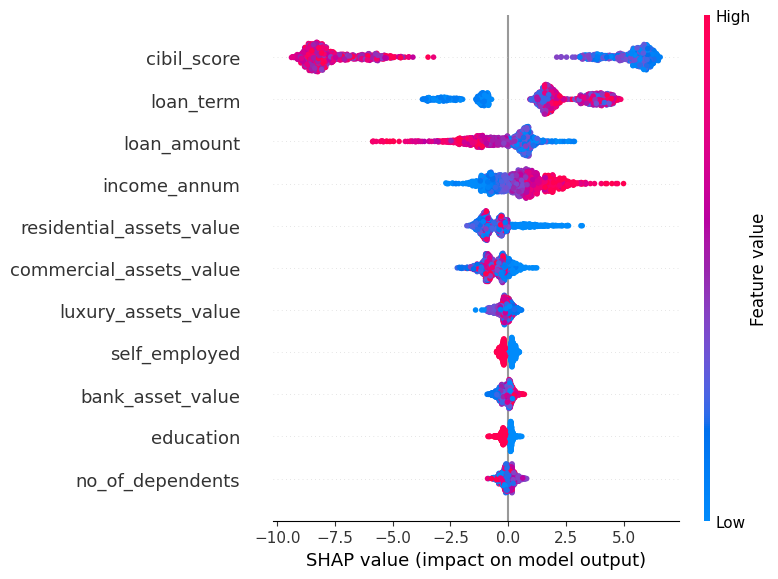

In [ ]:
# need to find the best parameter for the xgboost model form gridsearchcv
# used for the shap

import shap
m=xgb.XGBClassifier().fit(X_train, y_train)
explainer_xgb = shap.TreeExplainer(m)

shap_values = explainer_xgb.shap_values(X_test)
shap.summary_plot(shap_values, X_test)


In [ ]:

# User input for prediction
print("Please enter the following details to predict loan approval status:")

no_of_dependents = int(input("Number of Dependents "))
education_input = input("Education (Graduate / Not Graduate): ").strip()
self_employed_input = input("Self Employed (Yes / No): ").strip()
income_annum = int(input("Annual Income: "))
loan_amount = int(input("Loan Amount: "))
loan_term = int(input("Loan Term: "))
cibil_score = int(input("CIBIL Score: "))
residential_assets_value = int(input("Residential Assets Value: "))
commercial_assets_value = int(input("Commercial Assets Value: "))
luxury_assets_value = int(input("Luxury Assets Value: "))
bank_asset_value = int(input("Bank Asset Value: "))

# Map categorical inputs to numerical values as used during training
# 'Graduate' -> 0, 'Not Graduate' -> 1
education_encoded = 0 if education_input.lower() == 'graduate' else 1
# 'No' -> 0, 'Yes' -> 1
self_employed_encoded = 0 if self_employed_input.lower() == 'no' else 1

# Create a DataFrame for the new input
user_input_df = pd.DataFrame([{
    'no_of_dependents': no_of_dependents,
    'education': education_encoded,
    'self_employed': self_employed_encoded,
    'income_annum': income_annum,
    'loan_amount': loan_amount,
    'loan_term': loan_term,
    'cibil_score': cibil_score,
    'residential_assets_value': residential_assets_value,
    'commercial_assets_value': commercial_assets_value,
    'luxury_assets_value': luxury_assets_value,
    'bank_asset_value': bank_asset_value
}])

prediction = xg_b.predict(user_input_df)

prediction_status = "Approved" if prediction[0] == 0 else "Rejected" # Based on the original df['loan_status'] mapping, Approved was 1 and Rejected was 0 in some cells, but `EZT5ynUBNFTP` changed it. Let's recheck.

prediction_status_map = {0: 'Rejected', 1: 'Approved'}
prediction_result = prediction_status_map[prediction[0]]

print(f"\nPredicted Loan Status: {prediction_result}")

Please enter the following details to predict loan approval status:


KeyboardInterrupt: Interrupted by user

streamlit


In [ ]:
!pip install streamlit pyngrok
!pip install imbalanced-learn

In [ ]:
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

# Train Model
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)

model = XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.1)
model.fit(X_train, y_train)

# Save the model and the list of column names
joblib.dump(model, 'loan_model.joblib')
joblib.dump(X.columns.tolist(), 'model_columns.joblib')

['model_columns.joblib']

In [ ]:
import joblib
joblib.dump(xg_b, 'loan_model.joblib')

['loan_model.joblib']

In [ ]:
import pandas as pd
import joblib
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split

df = pd.read_csv('loan_approval_dataset.csv')
df.columns = df.columns.str.strip()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].str.strip()

df['education'] = df['education'].map({'Graduate': 1, 'Not Graduate': 0})
df['self_employed'] = df['self_employed'].map({'Yes': 1, 'No': 0})
df['loan_status'] = df['loan_status'].map({'Approved': 1, 'Rejected': 0})

features = [
    'no_of_dependents', 'education', 'self_employed', 'income_annum',
    'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value',
    'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value'
]
X = df[features]
y = df['loan_status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3)
model.fit(X_train, y_train)

joblib.dump(model, 'loan_model.joblib')
joblib.dump(features, 'model_features.joblib')

['model_features.joblib']

In [ ]:
!pkill ngrok
!pkill streamlit

In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib

model = joblib.load('loan_model.joblib')
model_features = joblib.load('model_features.joblib')

st.set_page_config(page_title="Loan Approval Prediction")
st.title("Loan Approval Prediction")

no_of_dependents = st.number_input("Dependents", min_value=0)
education = st.selectbox("Education", ["Graduate", "Not Graduate"])
self_employed = st.selectbox("Self Employed", ["Yes", "No"])
income_annum = st.number_input("Annual Income", min_value=0)
loan_amount = st.number_input("Loan Amount", min_value=0)
loan_term = st.number_input("Loan Term (Years)", min_value=0)
cibil_score = st.number_input("CIBIL Score", min_value=0, max_value=1000)
res_assets = st.number_input("Residential Assets Value", min_value=0)
comm_assets = st.number_input("Commercial Assets Value", min_value=0)
lux_assets = st.number_input("Luxury Assets Value", min_value=0)
bank_assets = st.number_input("Bank Asset Value", min_value=0)

if st.button("Predict"):
    input_data = {
        'no_of_dependents': no_of_dependents,
        'education': 1 if education == "Graduate" else 0,
        'self_employed': 1 if self_employed == "Yes" else 0,
        'income_annum': income_annum,
        'loan_amount': loan_amount,
        'loan_term': loan_term,
        'cibil_score': cibil_score,
        'residential_assets_value': res_assets,
        'commercial_assets_value': comm_assets,
        'luxury_assets_value': lux_assets,
        'bank_asset_value': bank_assets
    }

    user_df = pd.DataFrame([input_data])[model_features]

    prediction = model.predict(user_df)

    if prediction[0] == 1:
        st.success("Loan Approved")
    else:
        st.error("Loan Rejected")

Overwriting app.py


In [ ]:
!streamlit run app.py --server.port 8501 --server.address 0.0.0.0 &>/content/streamlit.log &


In [ ]:
import sys
!{sys.executable} -m pip install pyngrok
from pyngrok import ngrok

ngrok.set_auth_token("39U60yWoTaYqKoiPTsQzb9rQyKB_3wSuNk5L3VqptvBcWCMbz")

In [ ]:
!pkill ngrok

In [ ]:
from pyngrok import ngrok
ngrok.kill()

In [ ]:
from pyngrok import ngrok

public_url = ngrok.connect(8501)
print("Streamlit App URL:", public_url)


Streamlit App URL: NgrokTunnel: "https://unbangled-deon-unpatrolled.ngrok-free.dev" -> "http://localhost:8501"
